##Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon

# Set seaborn style for better visuals
sns.set_theme(style="whitegrid")

##Loading the dataset

In [2]:
df = pd.read_csv("seda2023_cov_state_annual.csv")

# Quick look at the data
display(df.head())

,sedafips,year,enrl38,totenrl,perfrl,perblk,perhsp,perasn,pernam,peroth,perwht
0,1,2016,333794.06,743100.19,0.571,0.332,0.068,0.015,0.009,0.020,0.556
1,1,2017,337799.00,744817.31,0.578,0.330,0.074,0.015,0.009,0.022,0.549
2,1,2018,340453.00,742606.88,0.569,0.328,0.079,0.016,0.009,0.022,0.545
3,1,2019,339357.00,739726.00,0.560,0.325,0.084,0.016,0.009,0.024,0.542
4,1,2022,336749.00,747115.00,0.507,0.320,0.100,0.016,0.009,0.029,0.526


## Dataset Data Dictionary

This dataset is sourced from the **Stanford Education Data Archive (SEDA)**. Below is a breakdown of the key attributes used in this analysis:

### Geographic Identifier
* **`sedafips` (State FIPS Code):** FIPS (Federal Information Processing Standard) codes are standard two-digit numbers used by the U.S. government to uniquely identify states and territories (e.g., `1` is Alabama, `6` is California). SEDA prefixes this with "seda". In this project, this acts as the unique identifier for each state.

### Temporal Indicator
* **`year`:** Represents the spring of the academic year. For example, `2019` corresponds to the 2018–2019 academic school year.

### Enrollment Metrics
* **`enrl38`:** Total student enrollment in **grades 3 through 8**. SEDA focuses heavily on standardized testing, which is primarily administered in these grades.
* **`totenrl`:** **Total enrollment** across *all* grades in the state.

### Socio-Economic Indicator
* **`perfrl`:** The percentage of students eligible for **Free or Reduced-Price Lunch**. This is the standard proxy used in U.S. education data to measure student poverty and socio-economic status (e.g., `0.571` means 57.1% of the student body is eligible).

### Demographic Composition
These attributes represent the racial and ethnic breakdown of the student body. They are expressed as proportions (e.g., `0.332` = 33.2%) and generally sum to 1.0 for a given state and year.
* **`perwht`:** Percentage of White students.
* **`perblk`:** Percentage of Black students.
* **`perhsp`:** Percentage of Hispanic students.
* **`perasn`:** Percentage of Asian students.
* **`pernam`:** Percentage of Native American students.
* **`peroth`:** Percentage of students identifying as Other or Multiracial.

##Correlation Heatmap Across All Variables
To understand the relationships between enrollment, socio-economic factors, and demographics.

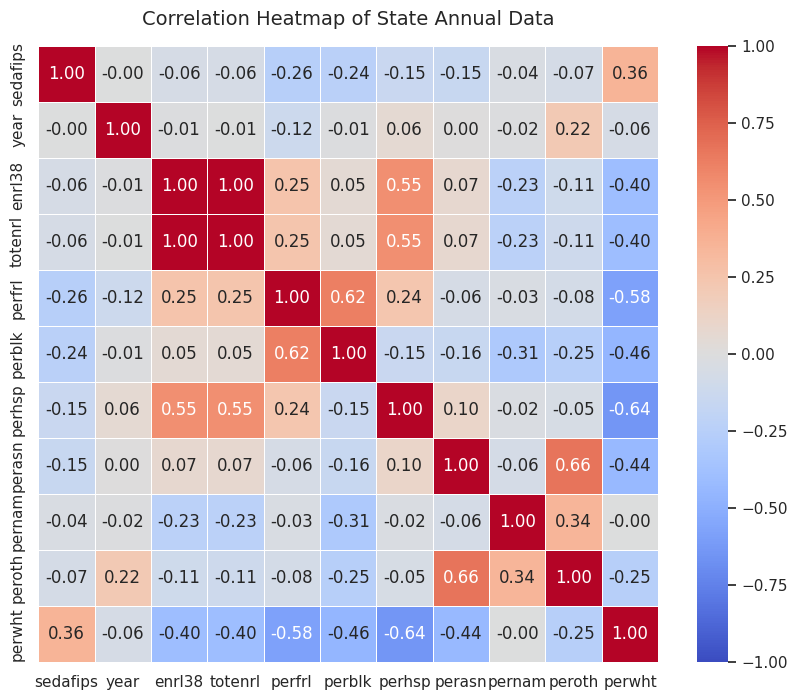

In [3]:
plt.figure(figsize=(10, 8))
# Calculate the correlation matrix for numeric columns
corr_matrix = df.corr(numeric_only=True)

# Generate a heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Heatmap of State Annual Data", fontsize=14, pad=15)
plt.show()

##Time Series of a Single State
To see the temporal trend more clearly, let's isolate a single state (FIPS code 6, which is California) and plot its total enrollment over time.

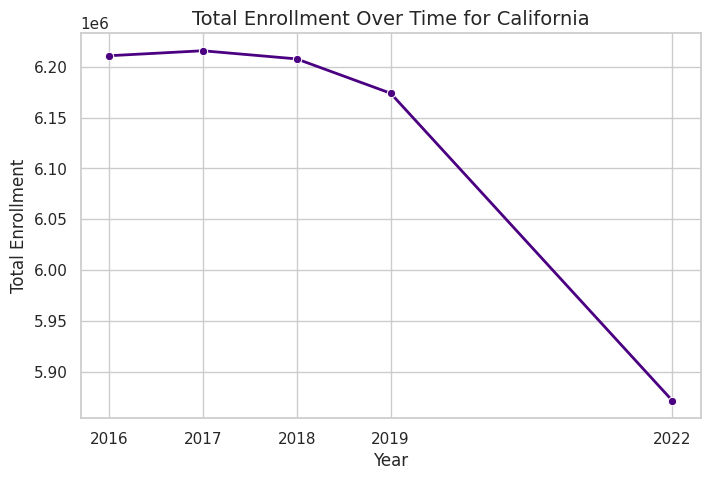

In [5]:
state_fips = 6
state_data = df[df['sedafips'] == state_fips].sort_values(by='year')

plt.figure(figsize=(8, 5))
sns.lineplot(data=state_data, x='year', y='totenrl', marker='o', linewidth=2, color='indigo')

plt.title(f"Total Enrollment Over Time for California", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Enrollment", fontsize=12)

# Ensure x-axis only shows the actual years in the dataset
plt.xticks(state_data['year'])
plt.show()

**Interpretation:**
The time series for California (FIPS 6) reveals a relatively stable public school enrollment between 2016 and 2018, hovering just above 6.2 million students. However, there is a minor dip in 2019, followed by a sharp decline in 2022, dropping to roughly 5.87 million students. This visualization supports the premise that the COVID-19 pandemic period (2020-2022) coincided with a major disruption and contraction in public school enrollment.

##Hypothesis 1: Economic Impact (Free/Reduced-Price Lunch)

**Background:** The percentage of students eligible for Free/Reduced-Price Lunch (`perfrl`) is a standard proxy for measuring economic hardship in student populations.

**Hypotheses:**
*   **Null Hypothesis ($H_0$):** There is no significant difference in the mean percentage of students eligible for free/reduced-price lunch between 2019 and 2022 ($\mu_{2019} = \mu_{2022}$).
*   **Alternate Hypothesis ($H_1$):** There is a significant difference in the mean percentage of students eligible for free/reduced-price lunch between 2019 and 2022 ($\mu_{2019} \neq \mu_{2022}$).


Hypothesis 1: Free/Reduced-Price Lunch (2019 vs 2022)
Mean perfrl 2019: 0.4885
Mean perfrl 2022: 0.4596
Paired t-test statistic: 3.6874, p-value: 5.5844e-04



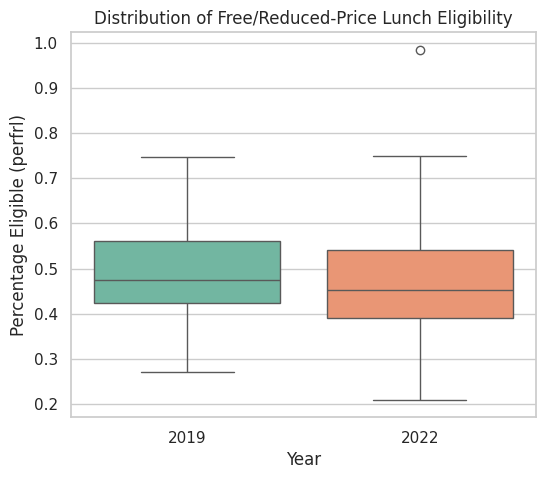

In [8]:
# Pivot data to get 2019 and 2022 perfrl side-by-side for each state
frl_wide = df.pivot(index="sedafips", columns="year", values="perfrl").dropna()

# Extract 2019 and 2022
frl_19 = frl_wide[2019]
frl_22 = frl_wide[2022]

# Perform Paired t-test
t_stat_frl, p_val_frl = ttest_rel(frl_19, frl_22)

print("Hypothesis 1: Free/Reduced-Price Lunch (2019 vs 2022)")
print(f"Mean perfrl 2019: {frl_19.mean():.4f}")
print(f"Mean perfrl 2022: {frl_22.mean():.4f}")
print(f"Paired t-test statistic: {t_stat_frl:.4f}, p-value: {p_val_frl:.4e}\n")

# Visualization: Boxplot
plot_data = frl_wide[[2019, 2022]].melt(var_name="Year", value_name="perfrl")
plt.figure(figsize=(6, 5))
# Added hue="Year" and legend=False to fix the FutureWarning
sns.boxplot(data=plot_data, x="Year", y="perfrl", hue="Year", legend=False, palette="Set2")
plt.title("Distribution of Free/Reduced-Price Lunch Eligibility", fontsize=12)
plt.ylabel("Percentage Eligible (perfrl)")
plt.show()

The paired t-test yields a p-value of roughly 0.0005, which is well below our standard significance level of 0.05. Therefore, we **reject the Null Hypothesis**.

The mean percentage of students eligible for Free/Reduced-Price Lunch actually **decreased** from 48.8% in 2019 to 45.9% in 2022. While the change is statistically significant, it does not point to a simple "worsening economy" narrative. Instead, this decline is likely due to structural shifts during the pandemic, such as:
1. **Federal Policy Changes:** Universal free lunch waivers during COVID-19 reduced the need for families to fill out the paperwork normally required to be counted in this metric.
2. **Disproportionate Disenrollment:** Lower-income students may have dropped out or shifted away from the public school system at higher rates than higher-income peers.

##Hypothesis 2: Demographic Shifts

**Background:** The pandemic caused significant geographic mobility (families moving) and changes in public vs. private school enrollment. We want to test if this caused a measurable shift in the racial/ethnic composition of state public school systems.

**Hypotheses:**
*   **Null Hypothesis ($H_0$):** There is no significant difference in the mean demographic percentages (e.g., Percent White, Percent Other) between 2019 and 2022 ($\mu_{2019} = \mu_{2022}$).
*   **Alternate Hypothesis ($H_1$):** There is a significant difference in the mean demographic percentages between 2019 and 2022 ($\mu_{2019} \neq \mu_{2022}$).


,Demographic,Mean 2019,Mean 2022,Change,P-Value
0,perwht,0.561431,0.543745,-0.017686,3.101366e-19
1,perblk,0.142902,0.140824,-0.002078,9.144012e-03
2,perhsp,0.181510,0.194627,0.013118,9.001580e-19
3,perasn,0.049255,0.049157,-0.000098,9.052528e-01
4,pernam,0.021137,0.020098,-0.001039,1.168453e-02
5,peroth,0.043902,0.051490,0.007588,1.177091e-16


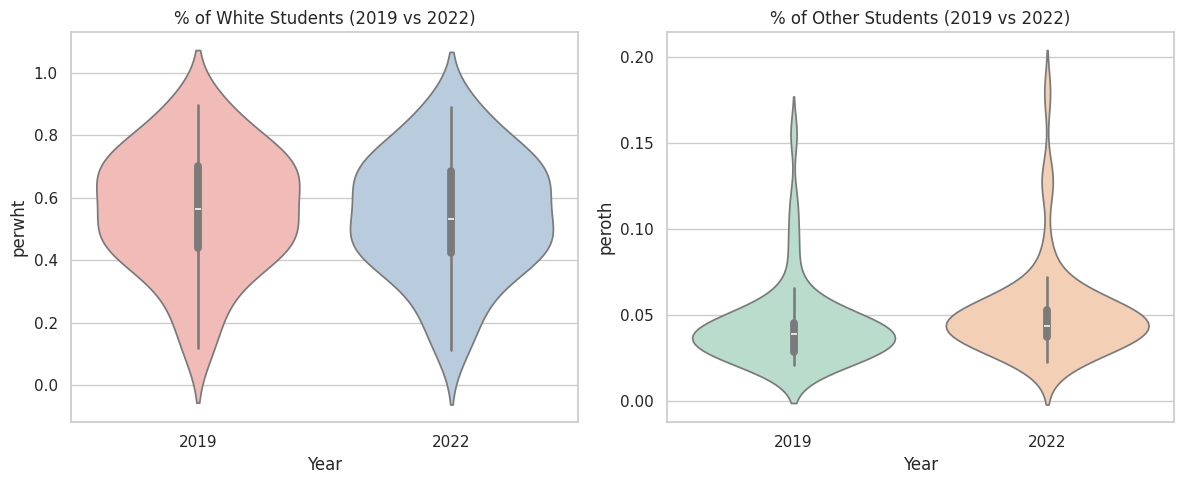

In [10]:
demographics = ['perwht', 'perblk', 'perhsp', 'perasn', 'pernam', 'peroth']
results = []

for demo in demographics:
    # Pivot data for each demographic
    demo_wide = df.pivot(index="sedafips", columns="year", values=demo).dropna()

    # Paired t-test
    t_stat, p_val = ttest_rel(demo_wide[2019], demo_wide[2022])

    results.append({
        "Demographic": demo,
        "Mean 2019": demo_wide[2019].mean(),
        "Mean 2022": demo_wide[2022].mean(),
        "Change": demo_wide[2022].mean() - demo_wide[2019].mean(),
        "P-Value": p_val
    })

# Display Results DataFrame
results_df = pd.DataFrame(results)
display(results_df)

# Visualizing the shifts for 'perwht' (Percent White) and 'peroth' (Percent Other)
wht_wide = df.pivot(index="sedafips", columns="year", values="perwht").dropna()[[2019, 2022]].melt(var_name="Year", value_name="perwht")
oth_wide = df.pivot(index="sedafips", columns="year", values="peroth").dropna()[[2019, 2022]].melt(var_name="Year", value_name="peroth")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Added hue="Year" and legend=False to fix the FutureWarning
sns.violinplot(data=wht_wide, x="Year", y="perwht", hue="Year", legend=False, ax=axes[0], palette="Pastel1")
axes[0].set_title("% of White Students (2019 vs 2022)")

sns.violinplot(data=oth_wide, x="Year", y="peroth", hue="Year", legend=False, ax=axes[1], palette="Pastel2")
axes[1].set_title("% of Other Students (2019 vs 2022)")

plt.tight_layout()
plt.show()

The data shows a highly significant structural shift in racial and ethnic composition during the pandemic:
* **Decreases:** The proportion of White and Black students saw a statistically significant decline across the states.
* **Increases:** The proportion of Hispanic and "Other/Multiracial" students saw a statistically significant increase.
* **No Change:** The Asian student population was the only group that remained statistically stable (p-value = 0.905).
